In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # for advanced statistical visualisations
from sklearn.preprocessing import MinMaxScaler # used for scaling

In [51]:
# loading the data
# we use a github link to acquire the data
url= "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# since the data has species column and nomalisation only work with numbers, we drop it
X = df.drop(columns=['species'])
print ('The original data is loaded with the Maximum original value (Sepal Length):', X ['sepal_length'].max())

The original data is loaded with the Maximum original value (Sepal Length): 7.9


In [52]:
# now we normalise the data to [0,1]
scaler_1 =MinMaxScaler(feature_range=(0,1))
# we fit, the fit transformer does this:
#1. fit find the Min and Max of the data
#2. transform applies the formula to every single number
normalized_data01 = scaler_1.fit_transform(X)
# converting to panda DataFrames for easy viewing
df_1= pd.DataFrame(normalized_data01, columns= X.columns)

In [53]:
# normalizing to [-5, 5]
scaler_neg55 =MinMaxScaler(feature_range=(-5,5))
normalized_data5 = scaler_neg55.fit_transform(X)
df_2 =pd.DataFrame(normalized_data5, columns=X.columns)

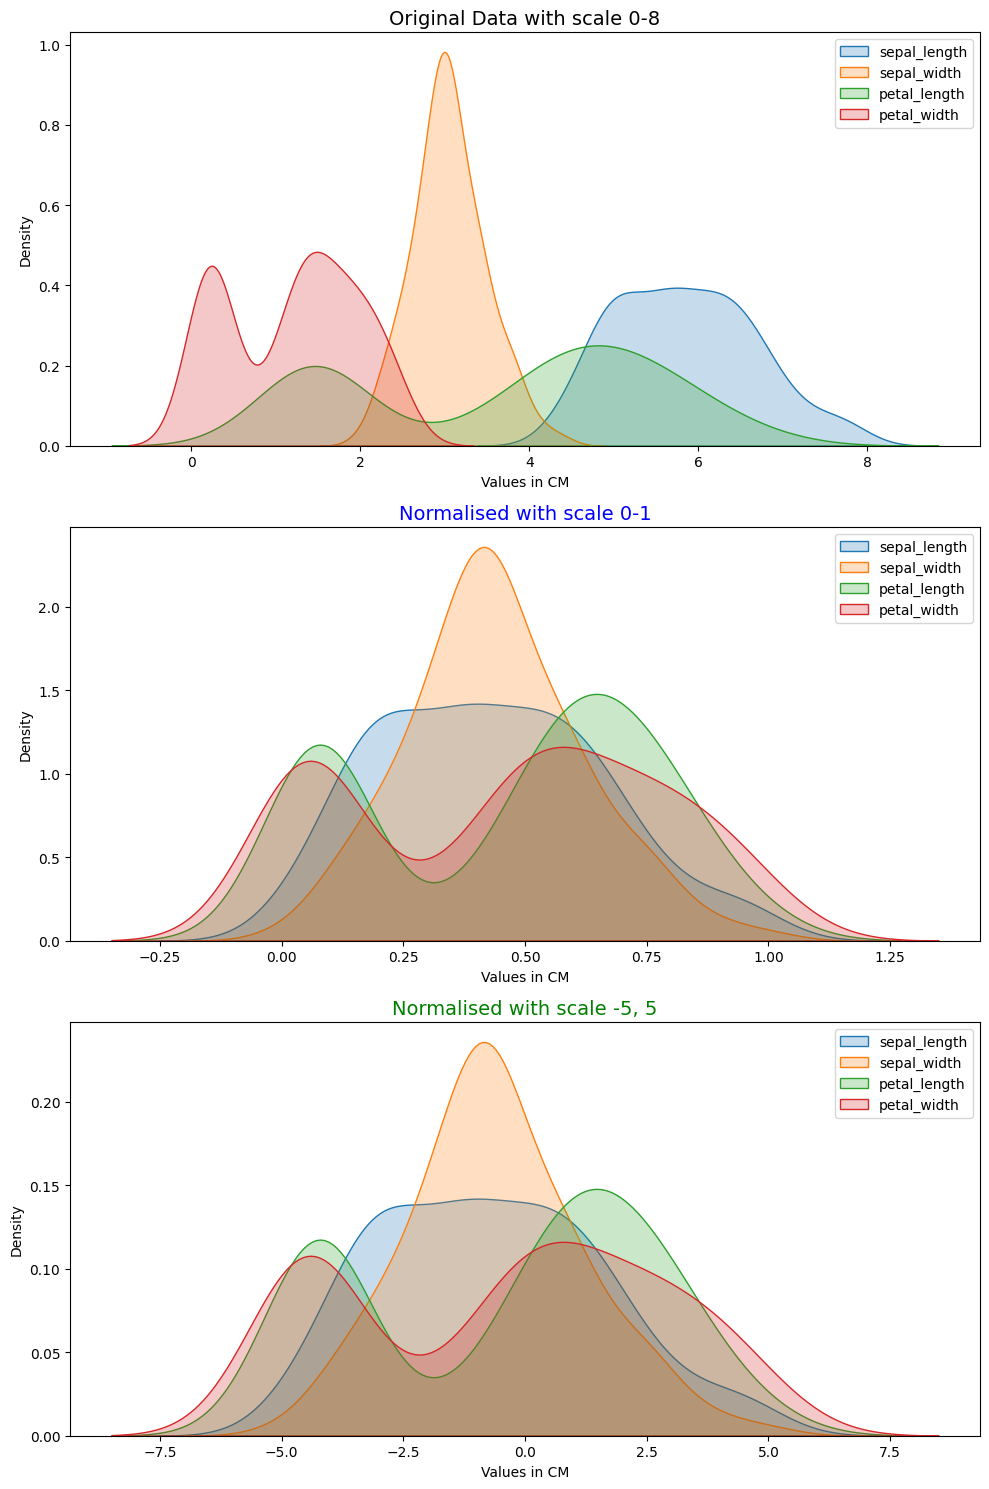

In [54]:
# visualizing and tracking the process
#  in this step we create 3 rows of plots to see hoe the X axis changes at each step
fig, axes =plt.subplots(3, 1, figsize= (10,15))

# this is the plot of the original dataset
for col in X.columns:
    sns.kdeplot(X[col], ax=axes[0], fill=True, label=col)
axes[0].set_title('Original Data with scale 0-8', fontsize=14)
axes[0].set_xlabel('Values in CM')

# plott after squeezing in 0-1
for col in df_1.columns:
    sns.kdeplot(df_1[col], ax=axes[1], fill=True, label=col)
axes[1].set_title('Normalised with scale 0-1', fontsize=14, color= 'blue')
axes[1].set_xlabel('Values in CM')

# plot by using th range of -5, 5
for col in df_2.columns:
    sns.kdeplot(df_2[col], ax=axes[2], fill=True, label =col)
axes[2].set_title('Normalised with scale -5, 5', fontsize= 14, color= 'green')
axes[2].set_xlabel('Values in CM')

for ax in axes:
    ax.legend()
# prevent overlapping
plt.tight_layout()
plt.show()



    

In [55]:
# saving the final files 
# index=False ensures we don't save the row numbers, just the data
df_1.to_csv('iris_normalized_0_1.csv', index=False)
df_2.to_csv('iris_normalized_neg5_5.csv', index=False)

print('Two CSV files saved to your folder')

Two CSV files saved to your folder
